<a href="https://colab.research.google.com/github/takatakamanbou/MVA/blob/2025/MVA2025_ex10notebookA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVA2025 ex10notebookA

<img width=64 src="https://www-tlab.math.ryukoku.ac.jp/~takataka/course/MVA/MVA-logo.png"> https://www-tlab.math.ryukoku.ac.jp/wiki/?MVA

---
## 多次元（多変量）正規分布 (2)
---



In [ ]:
# いつものいろいろインポート
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn
seaborn.set_theme()

# SciPy の 統計関数群の中の正規分布モジュール (scipy.stats.norm) と多変量正規分布モジュール (scipy.stats.multivariate_normal)
import scipy as sp
from scipy.stats import norm, multivariate_normal

---
## $1.$ 正規分布のパラメータの推定

正規分布にしたがって生み出されたと想定されるデータがあるときに，その正規分布のパラメータ（平均や分散共分散行列）を推定する問題を考えます．

### $1.1$ 確率密度（確率分布）の推定




次のようなデータ（1000人の身長，単位は[cm]）を考えます．

In [ ]:
# 1000人の (身長,体重) のデータ
dfHW = pd.read_csv('https://www-tlab.math.ryukoku.ac.jp/~takataka/course/ML/hw.csv', header=0)
# 身長だけ取り出す
dfHW['height']

,height
0,160.1
1,162.3
2,161.3
3,165.6
4,171.0
...,...
995,164.0
996,163.6
997,169.7
998,162.5


「これらのデータはある特定の確率分布に従って生成されたものだ」と仮定して，それがどんな確率分布であるかを推定することを考えましょう．例えば，上記のデータが正規分布に従うと仮定するなら，データからその平均と分散を推定する，ということです（下図参照）．

<img src="https://www-tlab.math.ryukoku.ac.jp/~takataka/course/MVA/density01.png">


上記のデータの場合，データの平均と分散を定義通りに求めると，次のようにそれら値が求められます．

In [ ]:
X = dfHW['height'].to_numpy()
mu = np.mean(X)
sig2 = np.var(X)
print(f'平均: {mu:.2f}  分散: {sig2:.2f}')

平均: 171.09  分散: 34.27


いまは，データが上の式で表される正規分布から生成された（母集団の確率分布が正規分布である）と考えています．この場合，その式の $\mu$ と $\sigma^2$ の値はこれらの値だったと推定できます（注）．

<hr width="50%" align="left">
<span style="font-size: 75%">
※注: 実は，このように求めた標本平均と標本分散の値をそのまま $\mu, \sigma^2$ の推定値とするとよくない場合があります．「最尤推定量は不偏推定量とは限らない」を参照してね．
</span>

ここで行っていることをまとめると，次のようになります：

1. 確率分布のモデル（データの背後にある確率分布を定める式，いまの例では正規分布）を仮定する
1. データからモデルのパラメータ（例では $\mu$ と $\sigma^2$）の具体的な値を推定する

このようにしてデータの背後にある確率密度（母集団の確率密度）を推定する，という問題は統計学の分野で古くから研究されており，**密度推定**（確率密度の推定）と呼ばれています（注）．

密度推定ができれば，次のようなことが可能となります．

- データの性質を記述できる．分析や理解が容易になる．
- 推定された分布を用いて新しいデータを生成できる．

モデルとなる確率分布としては正規分布の他にも様々なものがあり得ますが，以降では，最も典型的なものとして正規分布を取り上げて，この問題についてもう少し考えてみます．

<br>
<hr width="50%" align="left">
<span style="font-size: 75%">
※注: ここでは，モデルとして，正規分布のように少数のパラメータで表されるものを考えています．統計学では，このようなモデルを利用する手法は「パラメトリック(parametric)な手法」と呼ばれています．これに対して，モデルとして特定の確率分布を仮定しない手法もあり，「ノンパラメトリック(non-parametric)な手法」と呼ばれています．
ここで説明しているのは，パラメトリックな密度推定手法です．
</span>


---
### $1.2$ 正規分布のパラメータの推定

#### $1.2.1$ 1次元正規分布のパラメータ推定の問題設定

母集団の分布が1次元正規分布であると仮定できるときに，その正規分布のパラメータ（平均と分散）を推定する問題を考えます．

**［問題設定］** ある正規分布に従う母集団から $N$ 個の標本 $x_1, x_2, \ldots, x_N$ が抽出された．これらの値から，この母集団の平均と分散を推定したい．ただし，これらの標本は，すべて同一の1次元正規分布に従い，かつ独立に抽出されていると仮定する（注）．

<br>
<hr width="50%" align="left">
<span style="font-size: 75%">
※注: 個々の値が，同一の（平均や分散も同じ）分布から生み出されていると仮定できないと，そもそも平均や分散を一つ決めることができないですね．また，個々の値が独立でない，例えば，1つ目の値に応じて2つ目の値が決まる，というようなことがあってもやはり困ります（後述の最尤推定の話も参照）．このような「独立同一分布」の仮定は統計の問題でよく出てきます．Indenepdent and Identically ditributed の略として，i.i.d. と略記されていることもあります．
</span>

これは，その母集団から抽出した標本（データ）が与えられたときに，それらに最もよく当てはまる1次元正規分布（のパラメータ）を求める問題とも言えます．

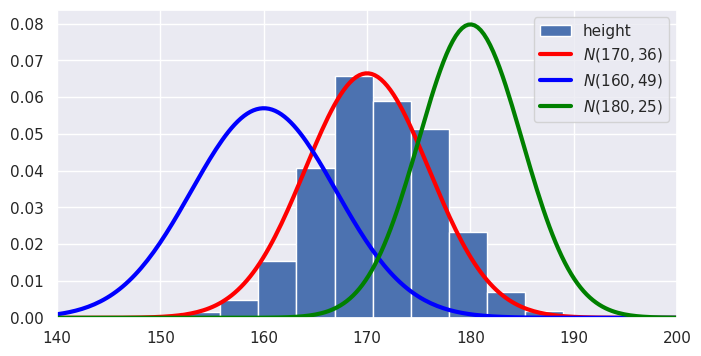

In [ ]:
# 身長のヒストグラムと3つの正規分布
fig, ax = plt.subplots(figsize=(8, 4))
xmin, xmax = 140, 200
xx = np.linspace(xmin, xmax, 200)
X = dfHW['height'].to_numpy()
ax.hist(X, density=True, label='height')
mu, sigma = 170, 6
fx = norm.pdf(xx, loc=mu, scale=sigma)
ax.plot(xx, fx, linewidth=3, color='red', label=f'$N({mu},{sigma*sigma})$')
mu, sigma = 160, 7
fx = norm.pdf(xx, loc=mu, scale=sigma)
ax.plot(xx, fx, linewidth=3, color='blue', label=f'$N({mu},{sigma*sigma})$')
mu, sigma = 180, 5
fx = norm.pdf(xx, loc=mu, scale=sigma)
ax.plot(xx, fx, linewidth=3, color='green', label=f'$N({mu},{sigma*sigma})$')
ax.set_xlim(xmin, xmax)
ax.legend()
plt.show()

平均と分散を変化させれば上図の曲線のように様々な正規分布が得られますが，このヒストグラムが表す標本に最も良く当てはまるのはどんな平均・分散をもつものだろう，という話です．

後述する「最尤推定」の考え方に基づいて「データに最もよく当てはまる」パラメータの推定値 $\widehat{\mu}, \widehat{\sigma}^2$ を求めると，次のようになります．
$$
\begin{aligned}
\widehat{\mu} &= \frac{1}{N}\sum_{n=1}^{N}x_n & (1)\\
\widehat{\sigma}^2 &= \frac{1}{N}\sum_{n=1}^{N}(x_n - \widehat{\mu})^2 & (2)
\end{aligned}
$$
これらは，それぞれデータの平均（標本平均）と分散（標本分散）ですね．

この結論は，一見当たり前のことのようにも思えます．ですがこの結論だけでは，「データに最もよく当てはまる」とはどういう意味かがわかりません．
次のセクションでその点を説明をします．

#### $1.2.2$ 最尤推定

「最尤」は「さいゆう」と読みます．「尤」は，「尤もらしい」＝「もっともらしい」で，「最も」＝「もっとも」と組み合わせて，「最も尤もらしい」ということになります．どういうことかは，以下で...．最尤推定は離散の確率分布でも考えられますが，ここでは連続の場合に限定して説明しています．

ある確率分布の確率密度関数が $f(x)$ であったときに，ある標本値 $x$ がこの確率分布から生成されたと考えることの「尤もらしさ（もっともらしさ）」を表す **尤度**（ゆう度，likelihood）を $\ell(x)$ と表し，次式で定めます．

$$
\ell(x) = f(x)
$$

$x$ を $f(x)$ に代入して得られた値をそのまま尤度の値とする，ということです．

具体的な例として，下図のように青色（右側）とオレンジ色（左側）の二つの正規分布を考えてみましょう．それぞれの正規分布の平均を $\mu_{\rm blue}, \mu_{\rm orange}$と表し，分散を$\sigma^2_{\rm blue}, \sigma^2_{\rm orange}$ と表すことにします．
あるデータ $x$ が青の正規分布から生成されたとすることの尤度を $\ell_{\rm blue}(x)$ とおき，オレンジの正規分布から生成されたとすることの尤度を $\ell_{\rm orange}(x)$ とおくと，それぞれ次式の通りとなります．
$$
\begin{aligned}
\ell_{\rm blue}(x) &= \frac{1}{\sqrt{2\pi\sigma_{\rm blue}^2}} \exp{\left( - \frac{(x-\mu_{\rm blue})^2}{2\sigma_{\rm blue}^2}\right)} \\
\ell_{\rm orange}(x) &= \frac{1}{\sqrt{2\pi\sigma_{\rm orange}^2}} \exp{\left( - \frac{(x-\mu_{\rm orange})^2}{2\sigma_{\rm orange}^2}\right)} \\
\end{aligned}
$$

<img src="https://www-tlab.math.ryukoku.ac.jp/~takataka/course/MVA/likelihood.png">

このとき，図の $x_1$ については，$\ell_{\rm blue}(x_1) > \ell_{\rm orange}(x_1)$ が成り立ち（$x_1$は青の正規分布から生成されたとする方が尤もらしい），$x_2$ については，$\ell_{\rm blue}(x_2) < \ell_{\rm orange}(x_2)$ が成り立ちます（$x_2$はオレンジの正規分布から生成されたとする方が尤もらしい）．このように，尤度は，ある決まったパラメータを持つ分布がデータにうまく当てはまる度合いを表します．

標本が $x_1, x_2, \ldots, x_N$ と複数ある場合の尤度は，同時確率を考えて $\ell(x_1, x_2, \ldots, x_N) = f(x_1, x_2, \ldots, x_N) $ と定義されます．いまは個々の標本が独立に得られると仮定しているので，これは次式のように個別の標本に対する尤度の積の形になります．
$$
\begin{aligned}
\ell(x_1, x_2, \ldots, x_N) &= f(x_1)\cdot f(x_2)\cdot\cdots\cdot f(x_N) = \prod_{n=1}^{N} f(x_n)
\end{aligned}
$$


上の図のピンクの点と灰色の点を全部合わせたものが標本全体だった場合，$\ell_{\rm blue}(x_1, x_2, \ldots, x_n) $ よりも $\ell_{\rm orange}(x_1, x_2, \ldots, x_n)$ の方が大きくなるでしょう．したがって，これらの標本全体はオレンジの方の正規分布から生成されたとする方がより尤もらしいと判断できます．

このような考え方に基づいて，尤度を規準として標本から確率分布のパラメータを推定する方法のことを，**最尤推定**(maximum likelihood estimation)または**最尤法**(maximum likelihood method)といいます．
実は，式$(1)$と$(2)$は，この最尤推定によって得られます．

#### $1.2.3$ 1次元正規分布のパラメータの最尤推定

1次元正規分布のパラメータを最尤推定によって推定すると，式$(1),(2)$が得られることを示します．
標本全体の尤度は上記のように個々の標本に対する尤度の積で書けます．
これを最大にするようにパラメータを決めればよい，ということになるのですが，積で表した式は扱いにくいので，対数をとったものを考えます．

$$
\begin{aligned}
L &= \log{\ell(x_1, x_2, \ldots, x_N)} = \log\left( \prod_{n=1}^{N} f(x_n) \right) \\
&= \sum_{n=1}^N\log {f(x_n)}
\end{aligned}
$$

これを，**対数尤度**(log-likelihood)といいます．$\log x$ は単調増加関数なので，尤度の最大化は対数尤度の最大化と等価です．

今は正規分布を考えていますので，推定したいパラメータの値を $\mu, \sigma^2$ とおくと，対数尤度 $L$ は次のように変形できます．

$$
\begin{aligned}
L &= \sum_{n=1}^N \log\left( \frac{1}{\sqrt{2\pi\sigma^2}} \exp{\left( - \frac{(x_n-\mu)^2}{2\sigma^2}\right)} \right)\\
&= \sum_{n=1}^N \left( -\frac{1}{2}\log{\left(2\pi\sigma^2\right)} - \frac{(x_n-\mu)^2}{2\sigma^2}\right) \\
&= -\frac{N}{2}\log{2\pi} - \frac{N}{2}\log\sigma^2-\frac{1}{2\sigma^2}\sum_{n=1}^N(x_n-\mu)^2 \qquad (*)
\end{aligned}
$$

$L$を最大にする$\mu,\sigma^2$ を求めたい，ということなので，いつものように微分して $0$ とおく作戦を採ると，式$(1),(2)$が得られます（notebookB の方でその確認を行うことにします）．


身長のデータに1次元正規分布を当てはめて平均と分散を最尤推定してみると，次のようになります．

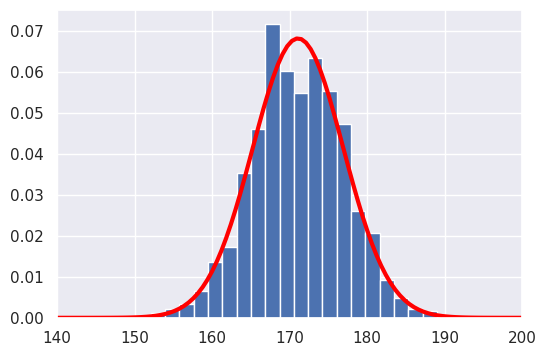

平均: 171.09  分散: 34.27


In [ ]:
# 標本
X = dfHW['height'].to_numpy()

# 平均と分散を推定
mu = np.mean(X)
sig2 = np.var(X)

# データのヒストグラムと推定された正規分布を描く
xx = np.linspace(140, 200, num=100)
px = norm.pdf(xx, loc=mu, scale=np.sqrt(sig2))
fig, ax = plt.subplots(1, facecolor="white", figsize=(6, 4))
ax.hist(X, bins=20, density=True)
ax.plot(xx, px, linewidth=3, color='red')
ax.set_xlim(140, 200)
plt.show()
print(f'平均: {mu:.2f}  分散: {sig2:.2f}')

#### $1.2.4$ 多次元正規分布のパラメータ推定

多次元正規分布の場合にも，1次元の場合と同様にパラメータ（平均と分散共分散行列）の最尤推定を考えることができます．

多次元正規分布に従う母集団から抽出された $N$ 個の標本を $\pmb{x}_1, \pmb{x}_2, \ldots, \pmb{x}_N$ （いずれも$D\times 1$行列とする）とするとき，この正規分布の平均と分散共分散行列の最尤推定量 $\widehat{\pmb{\mu}}$ と $\widehat{\Sigma}$ は次式のように与えられます（導出は省略します）．

$$
\begin{aligned}
\widehat{\pmb{\mu}} &= \frac{1}{N}\sum_{n=1}^{N}\pmb{x}_n & (3)\\
\widehat{\Sigma} &= \frac{1}{N}\sum_{n=1}^{N}(\pmb{x}_n-\widehat{\pmb{\mu}})(\pmb{x}_n-\widehat{\pmb{\mu}})^{\top} & (4)
\end{aligned}
$$

それぞれ，標本平均と標本分散共分散行列そのものです．


例として，(身長, 体重)のデータに2次元の正規分布を当てはめる実験をやってみましょう．

In [ ]:
dfHW

,height,weight
0,160.1,48.2
1,162.3,66.8
2,161.3,38.7
3,165.6,52.3
4,171.0,65.4
...,...,...
995,164.0,45.0
996,163.6,47.9
997,169.7,60.7
998,162.5,50.0


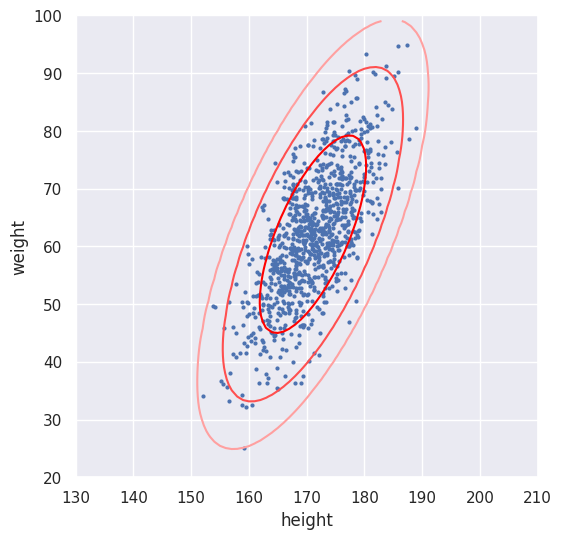

N = 1000  平均: [171.0903  62.0859]
分散共分散行列:
 [[ 34.26783591  43.82327323]
 [ 43.82327323 118.44415119]]


In [ ]:
# 標本
X = dfHW.to_numpy()
N, D = X.shape

# 平均と分散共分散行列を推定
mu = np.mean(X, axis=0)
cov = (X - mu).T @ (X - mu)/N

# グラフ描画用のグリッドデータの作成
xmin, xmax = 130, 210
ymin, ymax = 20, 100
xx, yy = np.mgrid[xmin:xmax:1, ymin:ymax:1]
zz = multivariate_normal.pdf(np.dstack((xx, yy)), mu ,cov)

# データの散布図と推定された正規分布の等高線を描く
fig, ax = plt.subplots(facecolor='white', figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], s=4)
ax.contour(xx, yy, zz, colors=['#ffa0a0', '#ff5050', '#ff0000'], levels=[0.00001, 0.0001, 0.001])
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('height')
ax.set_ylabel('weight')
ax.set_aspect('equal')
plt.show()
print(f'N = {N}  平均: {mu}')
print(f'分散共分散行列:\n {cov}')

### $1.3$ 最尤推定量は不偏推定量とは限らない

ここで登場する「不偏推定量」という概念は，大学初年次の確率統計の授業で学んでいると思います．詳しくはそちらの教科書や資料等を参照してください．

1次元正規分布および多次元正規分布のパラメータを標本値から最尤推定した際に得られる推定量は式$(1),(2)$ および $(3),(4)$で表されます．これらは，尤度を最大にするという意味で適切な推定量になっていますが，「不遍性」（推定量の期待値が真の値に等しくなるという性質）の点では適切でないものもあります．

式$(1),(3)$は「標本平均」であり，これらは母集団の平均の不偏推定量であることが知られています．一方，式$(2)$は「標本分散」と呼ばれるものですが，これは母集団の分散の不偏推定量ではありません（不遍性がない）．$N$個の標本から母集団の分散を推定する際の不偏推定量は，次式で定められる「不偏分散」です．

$$
\widetilde{\sigma}^2 = \frac{1}{N-1}\sum_{n=1}^{N}(x_n - \widehat{\mu})^2
$$

$N$ が大きければ標本分散と不偏分散の違いは小さいですが，$N$ が小さいときにはそれなりに大きな違いとなるので，注意が必要です．

同様に，式$(4)$で得られる「標本分散共分散行列」も不遍性がありません．こちらも，$N$の代わりに$N-1$で割ったものが不偏推定量となります．


---
## $2.$ マハラノビス距離

### $2.1$ 正規分布に対する尤度



データ（標本）が正規分布から生成されたと仮定してその正規分布のパラメータを推定すると，個々のデータの尤度を求められます．尤度が大きいデータは，その正規分布から生み出されたと考えるのが尤もらしく，尤度が小さいデータは，あまり尤もらしくありません．このように，一つの正規分布に対して個々のデータの尤度を求めると，それらのデータがその正規分布から生み出されたことの尤もらしさを数値で表せます．


2次元のデータの例で，実際に尤度を測ってみましょう．

In [ ]:
##### CSV ファイルを読み込む #####
URL = 'https://www-tlab.math.ryukoku.ac.jp/~takataka/course/MVA/MVA2024-QvsE1107.csv'
df = pd.read_csv(URL, index_col=0)
X = df.to_numpy()
N, D = X.shape
print(f'N = {N}, D = {D}')
#df

N = 121, D = 2


これは，MVA2024の第7回までの Quiz の得点率 [%]（Quiz）と小テストの得点率 [%]（Exam）のデータです．このデータに2次元正規分布を当てはめる（2次元正規分布から生成されたと仮定してその平均と分散共分散行列を推定する）と，次のような結果となります．

mu = [64.72694215 62.17123967]
cov = 
[[220.55010718 141.89147239]
 [141.89147239 243.95524226]]


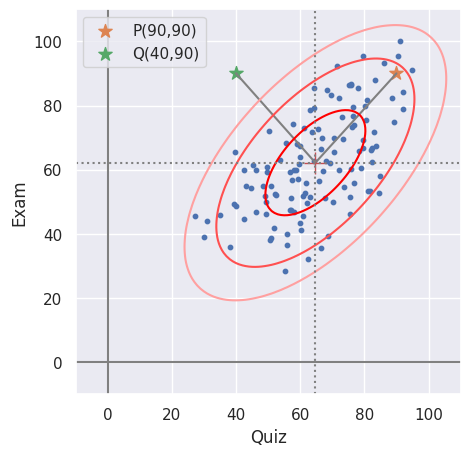

In [ ]:
# 平均 mu 分散共分散行列 cov を推定
mu = np.mean(X, axis=0)
print(f'mu = {mu}')
Xd = X - mu
cov = Xd.T @ Xd / N
print('cov = ')
print(cov)

# 2点 P, Q
P = np.array([90, 90])
Q = np.array([40, 90])

# 確率密度描画のためのグリッドデータの作成
xmin, xmax = -10, 110
xx, yy = np.mgrid[xmin:xmax:1.0, xmin:xmax:1.0]
zz = multivariate_normal.pdf(np.dstack((xx, yy)), mean=mu, cov=cov)

# データの散布図と正規分布の確率密度関数を重ねて描く
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], s=10)
ax.scatter(P[0], P[1], s=100, marker='*', label=f'P({P[0]},{P[1]})')
ax.scatter(Q[0], Q[1], s=100, marker='*', label=f'Q({Q[0]},{Q[1]})')
tmp = np.vstack((mu, P))
ax.plot(tmp[:, 0], tmp[:, 1], linestyle='-', color='gray')
tmp = np.vstack((mu, Q))
ax.plot(tmp[:, 0], tmp[:, 1], linestyle='-', color='gray')
ax.contour(xx, yy, zz, colors=['#ffa0a0', '#ff5050', '#ff0000'], levels=[0.00002, 0.0001, 0.0005])
ax.plot(mu[0], mu[1], '+', markersize=16, color='r')
ax.axvline(mu[0], linestyle='dotted', color='gray')
ax.axhline(mu[1], linestyle='dotted', color='gray')
ax.axvline(0, color='gray')
ax.axhline(0, color='gray')
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)
ax.set_xlabel('Quiz')
ax.set_ylabel('Exam')
ax.set_aspect('equal')
ax.legend()
plt.show()

この散布図には，正規分布の確率密度関数を可視化するための同心楕円と，2つの点 $P(90, 90), Q(40, 90)$ も描かれています．
2つの線分は，これらの点と正規分布の平均との間を結んでいます．

この2点 $P, Q$ は，この2次元平面上で，平均の点から同じくらい離れているように見えます．$P, Q$ がそれぞれ平均とどのくらい離れているかを測るため，ユークリッド距離（最も一般的な距離）を計算してみましょう．ある点 $\pmb{x}$ と $\pmb{y}$ の間のユークリッド距離は $\|\pmb{x} - \pmb{y}\|$ と表されます．

In [ ]:
# 平均と点PおよびQの間のユークリッド距離
v = mu - P
edistP = np.sqrt(v @ v)
v = mu - Q
edistQ = np.sqrt(v @ v)
print(f'平均と点 P({P[0]},{P[1]}) の間のユークリッド距離 = {edistP:.2f}')
print(f'平均と点 Q({Q[0]},{Q[1]}) の間のユークリッド距離 = {edistQ:.2f}')

平均と点 P(90,90) の間のユークリッド距離 = 37.59
平均と点 Q(40,90) の間のユークリッド距離 = 37.23


ユークリッド距離を測ると，$P, Q$ は平均からほぼ同じくらい離れていることが分かります．
しかし，図を見ると，点 $P$ は散らばったデータ点たちに近い所に位置している一方，点 $Q$ はそれらから少し離れています．

では，この正規分布に対する点$P,Q$の尤度の値はどうなるでしょうか．平均 $\pmb{\mu}$，分散共分散行列 $\Sigma$ の $D$ 次元正規分布の確率密度関数を $f(\pmb{x})$ とおくと，

$$
f(\pmb{x}) =
 \frac{1}{\sqrt{(2\pi)^D|\Sigma|}}\exp\left(-\frac{1}{2}(\pmb{x}-\pmb{\mu})^{\top}\Sigma^{-1}(\pmb{x}-\pmb{\mu})\right) \tag{5}
$$

です．この正規分布に対する $\pmb{x}$ の尤度を $\ell(\pmb{x})$ とおくと，$\ell(\pmb{x}) = f(\pmb{x})$ ですが，対数をとった値の方が扱いやすいので，**対数尤度** を求めると，

$$
\log\ell(\pmb{x}) = -\frac{D}{2}\log{(2\pi)} -\frac{1}{2}\log{|\Sigma|} - \frac{1}{2}(\pmb{x}-\pmb{\mu})^{\top}\Sigma^{-1}(\pmb{x}-\pmb{\mu}) \tag{6}
$$

となります．実際に，2点 $P,Q$ の対数尤度を計算してみると，次のようになります．

In [ ]:
# 推定された正規分布に対する点P, Qの対数尤度
llP = multivariate_normal.logpdf(P, mean=mu, cov=cov)
llQ = multivariate_normal.logpdf(Q, mean=mu, cov=cov)
print(f'推定された正規分布に対する点 P({P[0]},{P[1]}) の対数尤度 = {llP:.2f}')
print(f'推定された正規分布に対する点 Q({Q[0]},{Q[1]}) の対数尤度 = {llQ:.2f}')

推定された正規分布に対する点 P(90,90) の対数尤度 = -8.94
推定された正規分布に対する点 Q(40,90) の対数尤度 = -14.70


平均との間のユークリッド距離では点 $P, Q$ にほとんど差がありませんでしたが，対数尤度を測ると，$Q$ よりも $P$ の方がその値が大きく，この正規分布から生成された標本としてより尤もらしいことが分かります．このデータについては，$P(90, 90)$ の方が $Q(40, 90)$ よりも尤もらしい，つまり，両方90%のひとと，Quiz が40% で Exam が90% のひとでは，前者の方が現れがちであるといえます．

このように，尤度/対数尤度を用いると「対象とする正規分布から生成されたことの尤もらしさ」を評価することができます．


### $2.2$ マハラノビス距離

正規分布に対する尤度を求めると上記のような分析ができてうれしいですが，式(5)や(6)の計算はかなり面倒です．もうちょっと楽をすることを考えましょう．

式 $(6)$ をよく見ると，$\mu, \Sigma$ が固定されているとき、この対数尤度は次のような形をしています．

$$
\log\ell(\pmb{x}) = - \frac{1}{2}(\pmb{x}-\pmb{\mu})^{\top}\Sigma^{-1}(\pmb{x}-\pmb{\mu}) + (定数) \tag{7}
$$

$(定数)$ の項は $\pmb{x}$ によらず一定です．したがって，ある一つの正規分布に対する異なる2点の尤度の大小を比較するという目的においては，

$$
(\pmb{x}-\pmb{\mu})^{\top}\Sigma^{-1}(\pmb{x}-\pmb{\mu}) \tag{8}
$$

という量を計算すればよいことが分かります．ただし，式$(7)$にあった負号がなくなっているので，式$(8)$の値が小さい方が尤度が大きくなります（注1）．

以上をふまえて，ユークリッド距離に代わる新しい距離の規準として，次式で定義される **マハラノビス距離** (Mahalanobis' distance) （注2）を導入します．

$$
d(\pmb{x}) = \sqrt{(\pmb{x}-\pmb{\mu})^{\top}\Sigma^{-1}(\pmb{x}-\pmb{\mu})} \tag{9}
$$

このマハラノビス距離は，点 $\pmb{x}$ が，平均 $\pmb{\mu}$ 分散共分散行列 $\Sigma$ の正規分布からどのくらい離れているかを表す量です．特に，分散共分散行列 $\Sigma$ が単位行列に等しい場合，$M(\pmb{x}) = \sqrt{(\pmb{x}-\pmb{\mu})^{\top}(\pmb{x}-\pmb{\mu})} = \sqrt{\|\pmb{x} - \pmb{\mu}\|^2} = \|\pmb{x} - \pmb{\mu}\|$ となり，$\pmb{x}$ と $\pmb{\mu}$ の間のユークリッド距離に一致します．

<br>
<hr width="50%" align="left">
<span style="font-size: 75%">
※ 注1: 詳細は省きますが，この値は非負で，$0$ になるのは $\pmb{x} = \pmb{\mu}$ のときです．
<br>
※ 注2: マハラノビスは統計学者の名前です．
Prasanta Chandra Mahalanobis（プラサンタ・チャンドラ・マハラノビス）：  インドの統計学者， 1893 - 1972，<a href="https://ja.wikipedia.org/wiki/%E3%83%97%E3%83%A9%E3%82%B5%E3%83%B3%E3%82%BF%E3%83%BB%E3%83%81%E3%83%A3%E3%83%B3%E3%83%89%E3%83%A9%E3%83%BB%E3%83%9E%E3%83%8F%E3%83%A9%E3%83%8E%E3%83%93%E3%82%B9">Wikipedia</a>
</span>

上の例で推定された正規分布に対する点 $P, Q$ のマハラノビス距離の値を求めてみると，次のようになります．

In [ ]:
# 推定された正規分布に対する点P, Qのマハラノビス距離
covInv = np.linalg.inv(cov)
delta = P - mu
mdistP = np.sqrt(delta @ covInv @ delta)
delta = Q - mu
mdistQ = np.sqrt(delta @ covInv @ delta)
print(f'推定された正規分布に対する点 P({P[0]},{P[1]}) のマハラノビス距離 = {mdistP:.2f}')
print(f'推定された正規分布に対する点 Q({Q[0]},{Q[1]}) のマハラノビス距離 = {mdistQ:.2f}')

推定された正規分布に対する点 P(90,90) のマハラノビス距離 = 1.94
推定された正規分布に対する点 Q(40,90) のマハラノビス距離 = 3.91


対数尤度の大小を反映して，点$P$の方がマハラノビス距離が小さくなっています．

このように，尤度の大小を比較するという目的においては，より簡単に求められるマハラノビス距離をかわりに用いることができます．

ある正規分布に対する2つの点 $\pmb{x}_1, \pmb{x}_2$ のマハラノビス距離が等しいならば，この正規分布の確率密度関数を $f(\pmb{x})$ とおいて，$f(\pmb{x}_1) = f(\pmb{x}_2)$ が成り立ちます．上の図で描いている同心楕円は，確率密度の値が一定となる点の集合であり，マハラノビス距離一定の点の集合でもあります．


In [ ]:
_